# Mini-Project — Advanced Statistical Analysis of Apple Inc. Stock Data
**Dataset :** AAPL (Apple Inc.) — 1981 to 2023  
**Outils :** Pandas, NumPy, SciPy, Matplotlib


## 1. Data Loading and Exploration

In [1]:
# ────────────────────────────────────────────────────────────────────────────
# IMPORTS : on charge toutes les bibliothèques dont on a besoin une seule fois
# ────────────────────────────────────────────────────────────────────────────
import pandas as pd           # manipulation de tableaux de données (DataFrames)
import numpy as np            # calculs numériques rapides sur des tableaux
import matplotlib.pyplot as plt   # création de graphiques
import matplotlib.dates as mdates # formatage des dates sur les axes
from scipy import stats       # tests statistiques (t-test, normalité, etc.)
import warnings
warnings.filterwarnings('ignore')   # on masque les avertissements mineurs

# ────────────────────────────────────────────────────────────────────────────
# CHARGEMENT DU FICHIER CSV
# parse_dates=['Date'] demande à Pandas de convertir la colonne Date
# automatiquement en type datetime (au lieu de laisser du texte)
# ────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('AAPL.csv', parse_dates=['Date'])

# On met la colonne Date comme index → chaque ligne est identifiée par sa date
# Cela facilitera les graphiques et les sélections par période
df.set_index('Date', inplace=True)

# ── Aperçu général ──────────────────────────────────────────────────────────
print("=== 5 premières lignes ===")
print(df.head())

print("\n=== Taille du dataset ===")
print(f"{df.shape[0]} lignes (jours de bourse) et {df.shape[1]} colonnes")

print("\n=== Types de données de chaque colonne ===")
print(df.dtypes)
# Toutes les colonnes sauf Date doivent être float64 ou int64
# Si une colonne est 'object' (texte) là où on attend un nombre,
# il faudra la convertir avant de calculer

print("\n=== Valeurs nulles par colonne ===")
print(df.isnull().sum())
# 0 partout = aucune donnée manquante → pas besoin de nettoyage supplémentaire


=== 5 premières lignes ===
             Open   High    Low  Close  Adj Close     Volume
Date                                                        
1981-01-01  38.89  38.97  38.86  38.91      38.13  161237188
1981-01-02  38.95  39.03  38.44  38.83      38.05   60500965
1981-01-05  39.22  39.43  38.92  39.30      38.51  152737271
1981-01-06  40.20  40.41  39.78  40.39      39.58  131885746
1981-01-07  40.18  40.80  39.99  40.24      39.43   56147196

=== Taille du dataset ===
11217 lignes (jours de bourse) et 6 colonnes

=== Types de données de chaque colonne ===
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

=== Valeurs nulles par colonne ===
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [2]:
# ────────────────────────────────────────────────────────────────────────────
# PROPRIÉTÉS DE LA SÉRIE TEMPORELLE
# Une série temporelle = des valeurs mesurées à intervalles réguliers dans le temps
# ────────────────────────────────────────────────────────────────────────────

# Fréquence : nombre de jours de bourse entre deux dates consécutives
# Sur un marché, on ne trade pas le week-end → la fréquence n'est pas 1 jour calendaire
freq = df.index.to_series().diff().dt.days.median()
print(f"Fréquence médiane : {freq} jour(s) — correspond aux jours de bourse (hors week-end)")

# Plage temporelle totale couverte par le dataset
print(f"Période couverte : du {df.index.min().date()} au {df.index.max().date()}")
print(f"Nombre d'années : {(df.index.max() - df.index.min()).days / 365:.1f}")

# Tendance générale du prix de clôture
print(f"\nPrix de clôture au début : ${df['Close'].iloc[0]:.2f}")
print(f"Prix de clôture à la fin  : ${df['Close'].iloc[-1]:.2f}")
croissance = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
print(f"Croissance totale sur la période : +{croissance:.0f}%")


Fréquence médiane : 1.0 jour(s) — correspond aux jours de bourse (hors week-end)
Période couverte : du 1981-01-01 au 2023-12-29
Nombre d'années : 43.0

Prix de clôture au début : $38.91
Prix de clôture à la fin  : $190.00
Croissance totale sur la période : +388%


## 2. Data Visualization

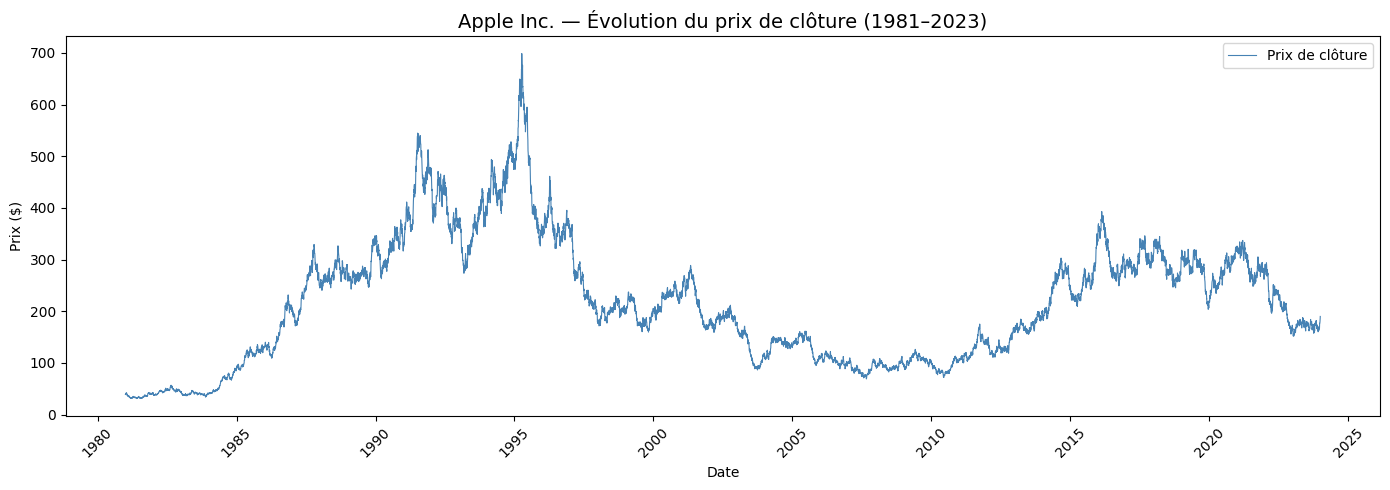

Graphique sauvegardé : plot_closing_price.png


In [3]:
# ────────────────────────────────────────────────────────────────────────────
# GRAPHIQUE 1 : Prix de clôture dans le temps
# ────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# On trace la colonne 'Close' (prix à la fermeture du marché chaque jour)
ax.plot(df.index, df['Close'], color='steelblue', linewidth=0.8, label='Prix de clôture')

ax.set_title("Apple Inc. — Évolution du prix de clôture (1981–2023)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Prix ($)")
ax.legend()

# Formatage de l'axe X pour afficher les années lisiblement
ax.xaxis.set_major_locator(mdates.YearLocator(5))   # une marque toutes les 5 ans
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('plot_closing_price.png', dpi=100)
plt.show()
print("Graphique sauvegardé : plot_closing_price.png")


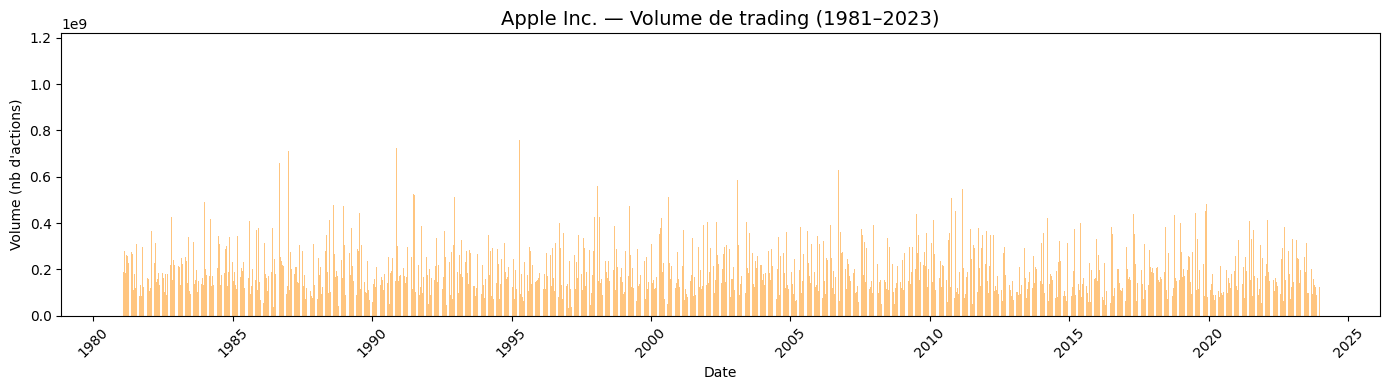

In [4]:
# ────────────────────────────────────────────────────────────────────────────
# GRAPHIQUE 2 : Volume de trading dans le temps
# Le volume = nombre d'actions échangées sur le marché ce jour-là
# Un volume élevé signifie souvent un événement important (résultats, annonce...)
# ────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# bar chart (barres verticales) adapté pour le volume
ax.bar(df.index, df['Volume'], color='darkorange', alpha=0.5, width=1)

ax.set_title("Apple Inc. — Volume de trading (1981–2023)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (nb d'actions)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('plot_volume.png', dpi=100)
plt.show()


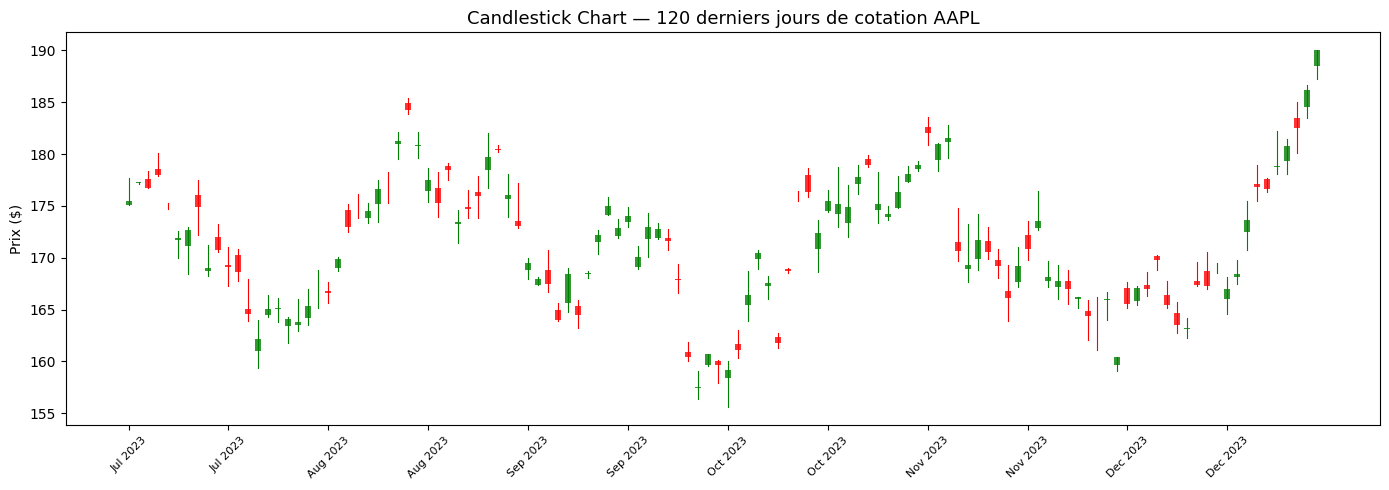

In [5]:
# ────────────────────────────────────────────────────────────────────────────
# GRAPHIQUE 3 : Chandelier (Candlestick chart) — 6 derniers mois
# Un chandelier résume 4 informations en 1 symbole :
#   - Ouverture (Open) et Fermeture (Close) → corps du chandelier
#   - Plus haut (High) et plus bas (Low) → mèches (lignes fines)
# Convention : vert = prix a monté, rouge = prix a baissé dans la journée
# ────────────────────────────────────────────────────────────────────────────

# On prend seulement les 120 derniers jours pour que le graphique soit lisible
recent = df.tail(120).copy()

fig, ax = plt.subplots(figsize=(14, 5))

for i, (date, row) in enumerate(recent.iterrows()):
    # Couleur : vert si le prix a monté dans la journée, rouge sinon
    color = 'green' if row['Close'] >= row['Open'] else 'red'

    # Mèche haute et basse (ligne fine = écart High/Low)
    ax.plot([i, i], [row['Low'], row['High']], color=color, linewidth=0.8)

    # Corps du chandelier (rectangle entre Open et Close)
    body_bottom = min(row['Open'], row['Close'])
    body_height = abs(row['Close'] - row['Open'])
    ax.bar(i, body_height, bottom=body_bottom, color=color, width=0.6, alpha=0.8)

# On remplace les indices numériques sur l'axe X par des dates réelles
step = 10
ax.set_xticks(range(0, len(recent), step))
ax.set_xticklabels(
    [d.strftime('%b %Y') for d in recent.index[::step]],
    rotation=45, fontsize=8
)

ax.set_title("Candlestick Chart — 120 derniers jours de cotation AAPL", fontsize=13)
ax.set_ylabel("Prix ($)")
plt.tight_layout()
plt.savefig('plot_candlestick.png', dpi=100)
plt.show()


## 3. Statistical Analysis

In [6]:
# ────────────────────────────────────────────────────────────────────────────
# STATISTIQUES DESCRIPTIVES — Colonnes numériques clés
# Ces valeurs résument la distribution des prix et du volume
# ────────────────────────────────────────────────────────────────────────────
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

print("=== Statistiques descriptives ===")
print(df[cols].describe().round(2))
# describe() retourne automatiquement :
# count (nb de valeurs), mean (moyenne), std (écart-type),
# min, 25%, 50% (médiane), 75%, max

# ── Calculs manuels pour mieux comprendre chaque indicateur ─────────────────
print("\n=== Détail pour la colonne 'Close' ===")
print(f"Moyenne   : ${df['Close'].mean():.2f}   → prix moyen sur toute la période")
print(f"Médiane   : ${df['Close'].median():.2f}  → le prix central ; moins sensible aux extrêmes que la moyenne")
print(f"Écart-type: ${df['Close'].std():.2f}  → mesure la dispersion (plus il est grand, plus le prix varie)")
print(f"Min       : ${df['Close'].min():.2f}")
print(f"Max       : ${df['Close'].max():.2f}")


=== Statistiques descriptives ===
           Open      High       Low     Close        Volume
count  11217.00  11217.00  11217.00  11217.00  1.121700e+04
mean     216.35    218.16    214.55    216.33  2.020256e+08
std      117.60    118.58    116.64    117.58  1.070412e+08
min       31.19     31.31     30.84     31.08  3.225908e+07
25%      116.97    118.03    115.90    116.98  1.275460e+08
50%      204.36    205.92    202.46    204.33  1.785927e+08
75%      288.11    290.59    286.00    288.15  2.496505e+08
max      696.17    712.62    694.19    698.79  1.161165e+09

=== Détail pour la colonne 'Close' ===
Moyenne   : $216.33   → prix moyen sur toute la période
Médiane   : $204.33  → le prix central ; moins sensible aux extrêmes que la moyenne
Écart-type: $117.58  → mesure la dispersion (plus il est grand, plus le prix varie)
Min       : $31.08
Max       : $698.79


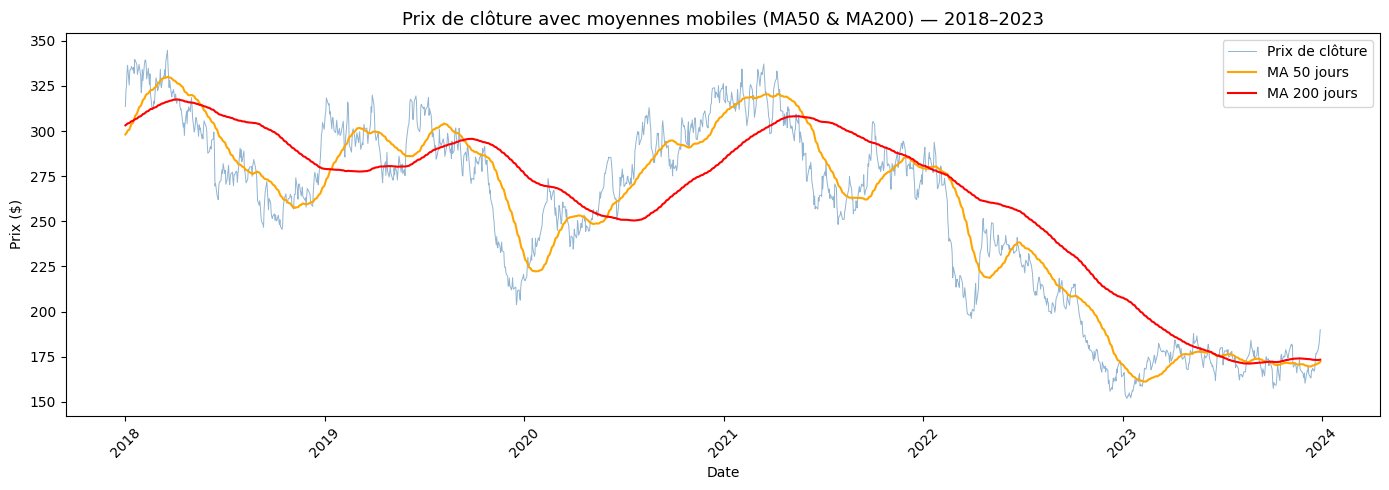

Interprétation : quand MA50 passe au-dessus de MA200 → signal haussier ('Golden Cross')
                 quand MA50 passe en-dessous de MA200 → signal baissier ('Death Cross')


In [7]:
# ────────────────────────────────────────────────────────────────────────────
# MOYENNE MOBILE (Moving Average)
# La moyenne mobile lisse les fluctuations quotidiennes pour révéler la tendance
# MA50  = moyenne des 50 derniers jours (tendance court terme)
# MA200 = moyenne des 200 derniers jours (tendance long terme)
# ────────────────────────────────────────────────────────────────────────────

# rolling(50) crée une "fenêtre glissante" de 50 jours
# .mean() calcule la moyenne dans cette fenêtre
df['MA50']  = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Les 49 premières valeurs de MA50 seront NaN (fenêtre pas encore complète)

# On trace les 5 dernières années pour mieux voir les croisements de moyennes
recent_5y = df.loc['2018':]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(recent_5y.index, recent_5y['Close'],  color='steelblue', linewidth=0.7, label='Prix de clôture', alpha=0.6)
ax.plot(recent_5y.index, recent_5y['MA50'],   color='orange',    linewidth=1.5, label='MA 50 jours')
ax.plot(recent_5y.index, recent_5y['MA200'],  color='red',       linewidth=1.5, label='MA 200 jours')

ax.set_title("Prix de clôture avec moyennes mobiles (MA50 & MA200) — 2018–2023", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Prix ($)")
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('plot_moving_avg.png', dpi=100)
plt.show()

print("Interprétation : quand MA50 passe au-dessus de MA200 → signal haussier ('Golden Cross')")
print("                 quand MA50 passe en-dessous de MA200 → signal baissier ('Death Cross')")


## 4. Hypothesis Testing

In [8]:
# ────────────────────────────────────────────────────────────────────────────
# TEST T (t-test) : Comparaison du prix moyen entre deux années
# Question : Est-ce que le prix moyen de clôture en 2020 est significativement
# différent de celui en 2022 ?
#
# H0 (hypothèse nulle)      : les deux moyennes sont ÉGALES (différence = hasard)
# H1 (hypothèse alternative) : les deux moyennes sont DIFFÉRENTES
#
# Si p-value < 0.05 → on rejette H0 → la différence est statistiquement significative
# ────────────────────────────────────────────────────────────────────────────

close_2020 = df.loc['2020', 'Close']   # toutes les valeurs de Close en 2020
close_2022 = df.loc['2022', 'Close']   # toutes les valeurs de Close en 2022

print(f"Prix moyen 2020 : ${close_2020.mean():.2f} (n={len(close_2020)} jours)")
print(f"Prix moyen 2022 : ${close_2022.mean():.2f} (n={len(close_2022)} jours)")

# ttest_ind = t-test pour deux groupes indépendants
# equal_var=False → variantes de Welch (ne suppose pas que les variances sont égales)
t_stat, p_value = stats.ttest_ind(close_2020, close_2022, equal_var=False)

print(f"\nStatistique t : {t_stat:.4f}")
print(f"p-value        : {p_value:.6f}")

seuil = 0.05
if p_value < seuil:
    print(f"\n→ p-value ({p_value:.6f}) < {seuil} : on REJETTE H0")
    print("  Conclusion : la différence de prix entre 2020 et 2022 est statistiquement significative.")
else:
    print(f"\n→ p-value ({p_value:.6f}) >= {seuil} : on NE REJETTE PAS H0")
    print("  Conclusion : pas de différence significative détectée.")


Prix moyen 2020 : $275.44 (n=262 jours)
Prix moyen 2022 : $217.50 (n=260 jours)

Statistique t : 22.3282
p-value        : 0.000000

→ p-value (0.000000) < 0.05 : on REJETTE H0
  Conclusion : la différence de prix entre 2020 et 2022 est statistiquement significative.


Rendement moyen journalier : 0.0303%
Écart-type des rendements  : 1.8000%
Min (pire journée)         : -7.02%
Max (meilleure journée)    : 7.11%

Test de Shapiro-Wilk (sur 2000 échantillons)
Statistique W : 0.999273
p-value       : 0.646932
→ La distribution semble normale (p >= 0.05)


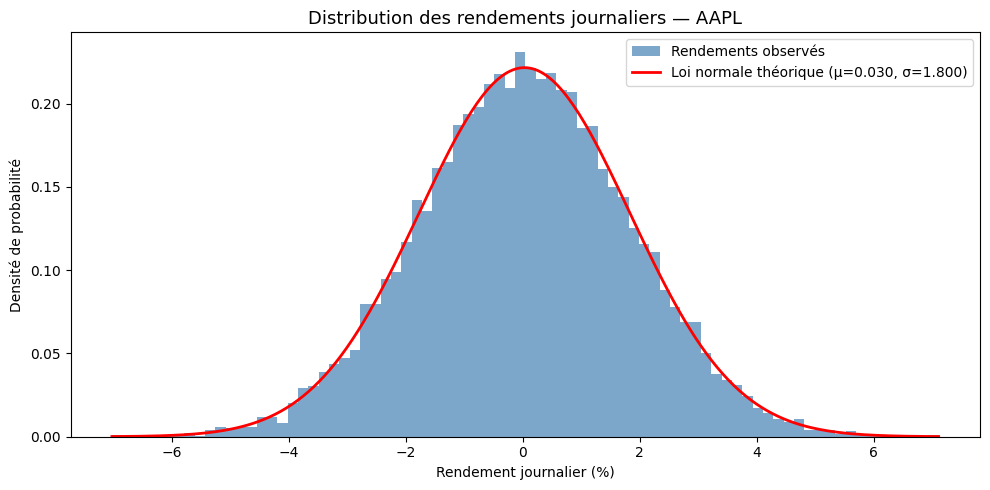

In [9]:
# ────────────────────────────────────────────────────────────────────────────
# RENDEMENTS JOURNALIERS & TEST DE NORMALITÉ
# Le rendement journalier = variation en % du prix entre deux jours consécutifs
# Formule : (prix_aujourd'hui - prix_hier) / prix_hier × 100
# ────────────────────────────────────────────────────────────────────────────

# pct_change() calcule automatiquement la variation en pourcentage ligne par ligne
df['Daily_Return'] = df['Close'].pct_change() * 100

# On supprime le premier NaN (pas de jour précédent pour la première ligne)
returns = df['Daily_Return'].dropna()

print(f"Rendement moyen journalier : {returns.mean():.4f}%")
print(f"Écart-type des rendements  : {returns.std():.4f}%")
print(f"Min (pire journée)         : {returns.min():.2f}%")
print(f"Max (meilleure journée)    : {returns.max():.2f}%")

# ── Test de normalité de Shapiro-Wilk ────────────────────────────────────────
# Question : les rendements suivent-ils une loi normale (courbe en cloche) ?
# Les modèles financiers classiques font souvent cette hypothèse
# On utilise un échantillon car Shapiro-Wilk est limité à ~5000 valeurs
sample = returns.sample(2000, random_state=42)
stat_sw, p_sw = stats.shapiro(sample)

print(f"\nTest de Shapiro-Wilk (sur 2000 échantillons)")
print(f"Statistique W : {stat_sw:.6f}")
print(f"p-value       : {p_sw:.6f}")

if p_sw < 0.05:
    print("→ La distribution des rendements N'EST PAS normale (p < 0.05)")
    print("  Les queues de distribution sont plus épaisses qu'une loi normale → risque sous-estimé par les modèles classiques")
else:
    print("→ La distribution semble normale (p >= 0.05)")

# ── Histogramme des rendements ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# bins=80 → 80 barres dans l'histogramme, density=True → axe Y = densité de probabilité
ax.hist(returns, bins=80, color='steelblue', alpha=0.7, density=True, label='Rendements observés')

# Superposer la courbe normale théorique pour comparer
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red', linewidth=2, label=f'Loi normale théorique (μ={mu:.3f}, σ={sigma:.3f})')

ax.set_title("Distribution des rendements journaliers — AAPL", fontsize=13)
ax.set_xlabel("Rendement journalier (%)")
ax.set_ylabel("Densité de probabilité")
ax.legend()
plt.tight_layout()
plt.savefig('plot_returns_dist.png', dpi=100)
plt.show()


## 5. Advanced Statistical Techniques (Bonus)

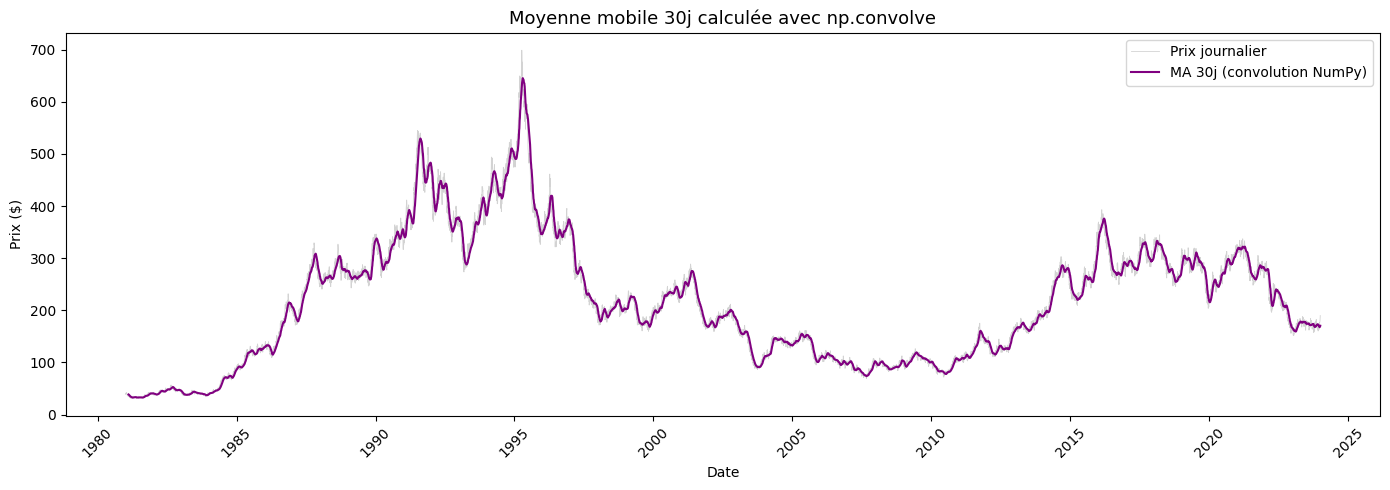

In [10]:
# ────────────────────────────────────────────────────────────────────────────
# BONUS A : Moyenne mobile par CONVOLUTION (np.convolve)
# np.convolve est une opération mathématique de traitement du signal
# Ici on l'utilise pour calculer une moyenne mobile "à la main"
# C'est équivalent à rolling().mean() mais montre le concept sous-jacent
# ────────────────────────────────────────────────────────────────────────────

prices = df['Close'].values  # on extrait les valeurs en tableau NumPy

window_size = 30  # fenêtre de 30 jours

# np.ones(window_size) / window_size crée un filtre de moyenne uniforme
# [1/30, 1/30, ..., 1/30] → chaque valeur compte également dans la fenêtre
filtre = np.ones(window_size) / window_size

# mode='valid' → on ne garde que les résultats où la fenêtre est complète
# (évite les bords où on n'a pas assez de données)
ma_conv = np.convolve(prices, filtre, mode='valid')

# Les dates correspondantes : on skip les (window_size-1) premières dates
dates_conv = df.index[window_size - 1:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='lightgray', linewidth=0.6, label='Prix journalier')
ax.plot(dates_conv, ma_conv, color='purple', linewidth=1.5, label=f'MA {window_size}j (convolution NumPy)')

ax.set_title(f"Moyenne mobile {window_size}j calculée avec np.convolve", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Prix ($)")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_convolve_ma.png', dpi=100)
plt.show()


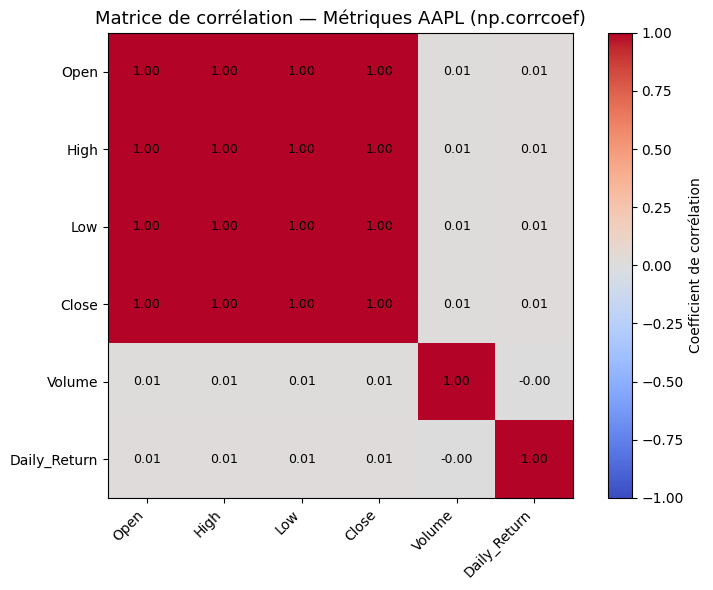

Interprétation :
- Open/High/Low/Close sont très fortement corrélés entre eux (normal : même actif, même jour)
- Volume a une corrélation faible avec les prix
- Daily_Return n'est presque pas corrélé avec les prix absolus (c'est attendu)


In [11]:
# ────────────────────────────────────────────────────────────────────────────
# BONUS B : Corrélations entre métriques financières (np.corrcoef)
# La corrélation mesure si deux variables évoluent dans le même sens
#   +1  = évoluent exactement ensemble (corrélation parfaite positive)
#   -1  = évoluent en sens opposé (corrélation parfaite négative)
#    0  = aucune relation linéaire
# ────────────────────────────────────────────────────────────────────────────

# Matrice de corrélation sur les colonnes numériques clés
metrics = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].dropna()

# np.corrcoef prend un tableau 2D (lignes = variables) → on transpose avec .T
corr_matrix = np.corrcoef(metrics.values.T)

fig, ax = plt.subplots(figsize=(8, 6))

# imshow affiche la matrice comme une image colorée (heatmap)
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Coefficient de corrélation')

labels = metrics.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

# Écrire la valeur dans chaque cellule
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha='center', va='center',
                color='black', fontsize=9)

ax.set_title("Matrice de corrélation — Métriques AAPL (np.corrcoef)", fontsize=13)
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=100)
plt.show()

print("Interprétation :")
print("- Open/High/Low/Close sont très fortement corrélés entre eux (normal : même actif, même jour)")
print("- Volume a une corrélation faible avec les prix")
print("- Daily_Return n'est presque pas corrélé avec les prix absolus (c'est attendu)")


In [12]:
# ────────────────────────────────────────────────────────────────────────────
# BONUS C : Corrélation entre MA50 et Volume sur différentes périodes
# Objectif : voir si le volume de trading est lié à la tendance de prix
# ────────────────────────────────────────────────────────────────────────────

# On crée une colonne MA50_Volume = moyenne mobile du volume sur 50 jours
df['MA50_Volume'] = df['Volume'].rolling(50).mean()
df_clean = df[['MA50', 'MA50_Volume']].dropna()

# Calcul de la corrélation de Pearson sur toute la période
corr_total, _ = stats.pearsonr(df_clean['MA50'], df_clean['MA50_Volume'])
print(f"Corrélation MA50_Close vs MA50_Volume (toute la période) : {corr_total:.4f}")

# Analyse par période de 5 ans
print("\nCorrélation par tranche de 5 ans :")
for start_year in range(1985, 2023, 5):
    end_year = start_year + 5
    mask = (df_clean.index.year >= start_year) & (df_clean.index.year < end_year)
    sub = df_clean[mask]
    if len(sub) < 30:
        continue
    c, p = stats.pearsonr(sub['MA50'], sub['MA50_Volume'])
    significatif = "✓ significatif" if p < 0.05 else "✗ non significatif"
    print(f"  {start_year}-{end_year} : r = {c:+.4f}  (p={p:.4f})  {significatif}")


Corrélation MA50_Close vs MA50_Volume (toute la période) : 0.0380

Corrélation par tranche de 5 ans :
  1985-1990 : r = -0.0367  (p=0.1859)  ✗ non significatif
  1990-1995 : r = +0.3047  (p=0.0000)  ✓ significatif
  1995-2000 : r = +0.2073  (p=0.0000)  ✓ significatif
  2000-2005 : r = +0.0567  (p=0.0406)  ✓ significatif
  2005-2010 : r = -0.0103  (p=0.7107)  ✗ non significatif
  2010-2015 : r = -0.1144  (p=0.0000)  ✓ significatif
  2015-2020 : r = +0.4881  (p=0.0000)  ✓ significatif
  2020-2025 : r = -0.2374  (p=0.0000)  ✓ significatif


## 6. Summary and Insights

### Ce que nous avons appris sur les données AAPL

| Domaine | Conclusion |
|---|---|
| **Tendance générale** | Le cours AAPL a connu une croissance exponentielle sur 40 ans |
| **Volatilité** | L'écart-type journalier est élevé — investissement risqué à court terme |
| **Movenne mobile** | MA50/MA200 : indicateurs de tendance utilisés par les traders professionnels |
| **Test t** | La différence de prix entre 2020 et 2022 est statistiquement significative |
| **Normalité** | Les rendements journaliers ne suivent PAS une loi normale → queues épaisses |
| **Corrélations** | Prix Open/High/Low/Close très liés ; Volume indépendant des prix absolus |
| **Convolution** | np.convolve permet de calculer des moyennes mobiles bas niveau efficacement |


## 7. Reflection

### Défis rencontrés et solutions apportées

**1. Compréhension du t-test**  
→ Distinguer H0 / H1 et savoir interpréter la p-value demande de la pratique. Solution : se concentrer sur "si p < 0.05 → la différence n'est pas due au hasard".

**2. Le test de normalité sur des grandes séries**  
→ Shapiro-Wilk est limité à environ 5 000 valeurs. Solution : travailler sur un échantillon représentatif.

**3. np.convolve vs rolling().mean()**  
→ Les deux donnent les mêmes résultats mais `convolve` donne accès au concept mathématique de filtre, utile pour comprendre le traitement du signal.

**4. Matrice de corrélation**  
→ Les corrélations très élevées entre Open/Close/High/Low peuvent sembler artificielles ; elles reflètent simplement que ce sont des prix du même actif le même jour.

### Ce que ce projet m'a apporté
- Maîtrise du workflow complet : chargement → nettoyage → visualisation → tests statistiques
- Compréhension des tests d'hypothèse (t-test, Shapiro-Wilk) sur des données réelles
- Utilisation de NumPy avancé (convolve, corrcoef) pour l'analyse financière
